In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import re

from setting_for_sdm.path_setting import path_list
from setting_for_sdm.date_setting import Date_Setting
from setting_for_sdm.constants import CONSTANTS

from lib.code_complexity.cognitive_complexity import calculate_cognitive_complexity
from lib.utils.file_io import read_complexity_parquet

import lib.stats.stats as st
from lib.utils.file_io import *
from lib.utils.statistics import *
from lib.utils.settings import set_matplotlib
from matplotlib import pyplot as plt

import matplotlib as mpl
import lib.visualization.plot_generator as PlotGen
import lib.visualization.font_setting as font_setting
mpl.rcParams['font.family'] = font_setting.init_font()

import statsmodels.formula.api as smf
from scipy import stats





Helvetica /home/mghan/.fonts/Helvetica/Helvetica Oblique.ttf
Registered font name: Helvetica


In [2]:
def draw_cognitive_complexity_scatter_plot(idx_num, viz_df, x_col, y_col, lang, output_dir, opt):
    sharey = False ## 또는 sharey=False
    sharex = True ## 또는 sharex=False

    fig, axs = mpl.pyplot.subplots(figsize = (12, 6), constrained_layout=True)

    plotgen = PlotGen.PlotGen()
    x= list(viz_df[x_col])
    y= list(viz_df[y_col])
    
    plotgen.draw_regression_with_chow(axs
                                , f'Cognitive Complexity for {lang}({opt})' 
                                , x
                                , y
                                , None
                                , None
                                , None
                                , False
                                )

    fig.supxlabel("Weeks relative to ChatGPT release", fontsize=22) 
    fig.supylabel('Weekly average reputation', fontsize=22)
    filename = f"{idx_num}_scatter_plot_{lang}_cognitive_complexity_{lang}_{opt}.png"
    plt.savefig(
    os.path.join(output_dir, filename),
    dpi=300,
    bbox_inches='tight'
    )
    plt.close(fig)

In [3]:
path_list["data_root_dir"]

'/mnt/hdd/mghan/so_difficulty_measure'

In [4]:
for idx, lang in enumerate(CONSTANTS.src_extend.keys()):
    print(f'[visualizing....] start visualizing {lang} language')
    output_dir = create_dir('./fig/')

    complexity_path = f'{path_list["data_root_dir"]}/result/code_complexity/run_id_{10000+idx}/data/all_complexity.parquet'
    reputation_path = f'{path_list["data_root_dir"]}/data/public_for_260105/reputation/{lang}/2020to2025/'

    complexity_df = pd.read_parquet(complexity_path)
    complexity_df['id'] = complexity_df['path'].apply(lambda x : x.split('_')[1].split('.')[0])
    complexity_df[['id', 'cognitive_complexity']] = complexity_df[['id', 'cognitive_complexity']].astype(int)

    reputation_df = load_df(reputation_path, ['id', 'owneruserid', 'creationdate','reputation'])

    merge_df = pd.merge(complexity_df, reputation_df, on = ['id']).copy()
    merge_df['reputation'] = merge_df['reputation'].fillna(0)

    merge_df['log_cognitive_complexity'] = np.log(merge_df['cognitive_complexity']+1)
    merge_df['log_reputation'] = np.log(np.abs(merge_df['reputation'])+1)

    merge_df['rel_week'] = np.floor((pd.to_datetime(merge_df['creationdate'], format='mixed')- datetime(2022,11,30)).dt.days/7)
    
    viz_df = merge_df.groupby(['creationdate', 'id'], as_index=False).max()[['creationdate', 'id', 'log_reputation', 'log_cognitive_complexity']]
    viz_df['rel_week'] = np.floor((pd.to_datetime(viz_df['creationdate'], format='mixed')- datetime(2022,11,30)).dt.days/28)
    viz_df = (viz_df.groupby('rel_week', as_index=False)['log_reputation'].mean())

    
    draw_cognitive_complexity_scatter_plot(idx, viz_df, 'rel_week', 'log_reputation', lang, output_dir, 'reputationXcomplexity')

[visualizing....] start visualizing python language


100%|██████████| 65/65 [00:01<00:00, 47.46it/s]


[visualizing....] start visualizing javascript language


100%|██████████| 65/65 [00:01<00:00, 64.10it/s]


[visualizing....] start visualizing java language


...

100%|██████████| 65/65 [00:00<00:00, 1962.83it/s]


[visualizing....] start visualizing f# language


100%|██████████| 65/65 [00:00<00:00, 2277.59it/s]


[visualizing....] start visualizing solidity language


100%|██████████| 65/65 [00:00<00:00, 1961.07it/s]


In [9]:
results = []

for idx, lang in enumerate(CONSTANTS.src_extend.keys()):
    print(f'[visualizing....] start visualizing {lang} language')
    output_dir = create_dir('./fig/')

    complexity_path = f'{path_list["data_root_dir"]}/result/code_complexity/run_id_{10000+idx}/data/all_complexity.parquet'
    reputation_path = f'{path_list["data_root_dir"]}/data/public_for_260105/reputation/{lang}/2020to2025/'

    complexity_df = pd.read_parquet(complexity_path)
    complexity_df['id'] = complexity_df['path'].apply(lambda x : x.split('_')[1].split('.')[0])
    complexity_df[['id', 'cognitive_complexity']] = complexity_df[['id', 'cognitive_complexity']].astype(int)

    reputation_df = load_df(reputation_path, ['id', 'owneruserid', 'creationdate','reputation'])

    merge_df = pd.merge(complexity_df, reputation_df, on = ['id']).copy()
    merge_df['reputation'] = merge_df['reputation'].fillna(0)

    merge_df['log_cognitive_complexity'] = np.log(merge_df['cognitive_complexity']+1)
    merge_df['log_reputation'] = np.log(np.abs(merge_df['reputation'])+1)

    merge_df['rel_week'] = np.floor((pd.to_datetime(merge_df['creationdate'], format='mixed')- datetime(2022,11,30)).dt.days/7)
    
    viz_df = merge_df.groupby(['creationdate', 'id'], as_index=False).max()[['creationdate', 'id', 'log_reputation', 'log_cognitive_complexity']]
    viz_df['rel_week'] = np.floor((pd.to_datetime(viz_df['creationdate'], format='mixed')- datetime(2022,11,30)).dt.days/28)
    viz_df = (viz_df.groupby('rel_week', as_index=False)['log_reputation'].mean())

    viz_df["post"]   = (viz_df["rel_week"] >= 0).astype(int)   # GPT 등장 후?
    viz_df["t"]      = viz_df["rel_week"]                       # 시간 추세
    viz_df["post_t"] = viz_df["post"] * viz_df["rel_week"]           # 추세 변화
    viz_df["log_y"]  = viz_df['log_reputation']            # log 변환

    X = sm.add_constant(viz_df[["t", "post", "post_t"]])
    m = sm.OLS(viz_df["log_y"], X).fit(cov_type="HAC", cov_kwds={"maxlags": 8})
    
    results.append({
        "language":     lang,
        # β₂: 즉각 점프
        "level_shift":  m.params["post"],
        "level_se":     m.bse["post"],
        "level_p":      m.pvalues["post"],
        # β₃: 추세 변화
        "slope_change": m.params["post_t"],
        "slope_se":     m.bse["post_t"],
        "slope_p":      m.pvalues["post_t"],
    })

[visualizing....] start visualizing python language


100%|██████████| 65/65 [00:01<00:00, 32.59it/s]


[visualizing....] start visualizing javascript language


100%|██████████| 65/65 [00:01<00:00, 43.78it/s]


[visualizing....] start visualizing java language


...

100%|██████████| 65/65 [00:00<00:00, 2938.36it/s]


[visualizing....] start visualizing f# language


100%|██████████| 65/65 [00:00<00:00, 1837.36it/s]


[visualizing....] start visualizing solidity language


100%|██████████| 65/65 [00:00<00:00, 2665.37it/s]


In [12]:
import numpy as np
import pandas as pd
import statsmodels.api as sm


gpt_df = pd.DataFrame(results)
gpt_df["level_sig"] = gpt_df["level_p"] < 0.05
gpt_df["slope_sig"] = gpt_df["slope_p"] < 0.05

In [18]:
lang_order = reversed(list(CONSTANTS.src_extend.keys()))

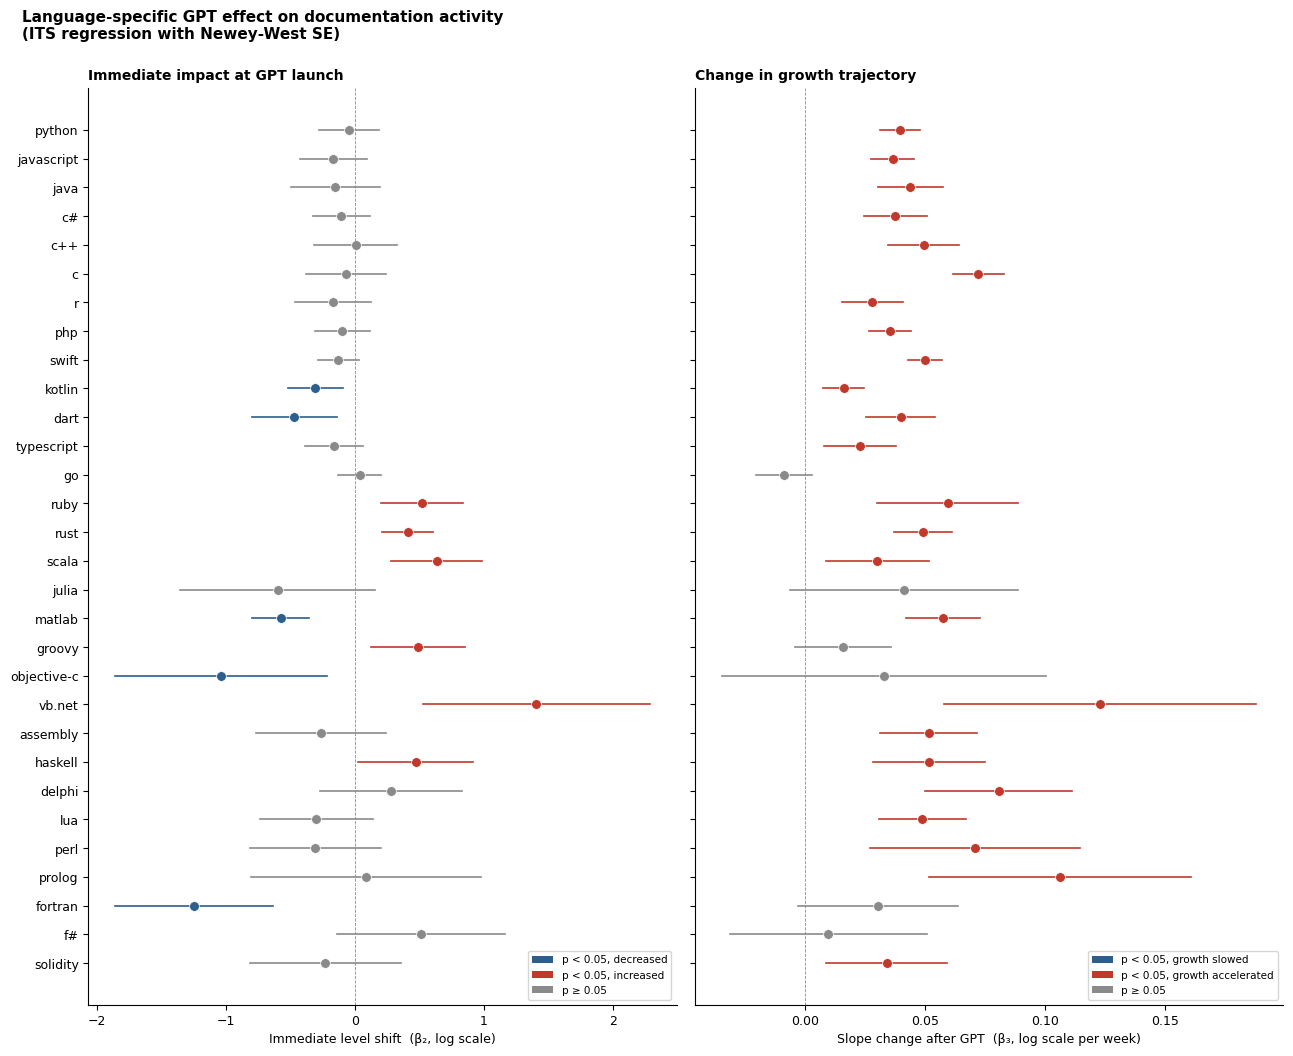

In [19]:
# ─────────────────────────────────────────────────────────
# 2. 정렬: β₂ 기준으로 (좌측 panel이 정렬 기준이 되도록)
#    공통 y축이라 한 번만 정렬하면 양쪽 panel 같이 따라옴
# ─────────────────────────────────────────────────────────
gpt_sorted = (gpt_df.set_index("language")
                    .loc[[l for l in lang_order if l in gpt_df["language"].values]]
                    .reset_index())
n = len(gpt_sorted)

# ─────────────────────────────────────────────────────────
# 3. 두 panel forest plot
# ─────────────────────────────────────────────────────────
mpl.rcParams.update({"font.family": "sans-serif", "font.size": 9, "axes.linewidth": 0.8})

fig, axes = plt.subplots(1, 2, figsize=(13, max(4, 0.35 * n)), sharey=True)

panels = [
    {
        "ax":      axes[0],
        "effect":  "level_shift",
        "se":      "level_se",
        "sig":     "level_sig",
        "xlabel":  "Immediate level shift  (β₂, log scale)",
        "title":   "Immediate impact at GPT launch",
        "neg_lbl": "decreased",
        "pos_lbl": "increased",
    },
    {
        "ax":      axes[1],
        "effect":  "slope_change",
        "se":      "slope_se",
        "sig":     "slope_sig",
        "xlabel":  "Slope change after GPT  (β₃, log scale per week)",
        "title":   "Change in growth trajectory",
        "neg_lbl": "growth slowed",
        "pos_lbl": "growth accelerated",
    },
]

for p in panels:
    ax = p["ax"]
    
    # 색깔: 각 panel의 자기 유의성/방향 기준으로
    colors = ["#2C5F8D" if r._asdict()[p["sig"]] and r._asdict()[p["effect"]] < 0
              else "#C0392B" if r._asdict()[p["sig"]] and r._asdict()[p["effect"]] > 0
              else "#8A8A8A"
              for r in gpt_sorted.itertuples()]
    
    
    for i, row in gpt_sorted.iterrows():
        eff = row[p["effect"]]
        se  = row[p["se"]]
        lo  = eff - 1.96 * se
        hi  = eff + 1.96 * se
        ax.plot([lo, hi], [i, i], color=colors[i], lw=1.2)
        ax.plot(eff, i, "o", color=colors[i],
                markersize=7, markeredgecolor="white", markeredgewidth=0.5)
    
    ax.axvline(0, color="0.55", lw=0.6, ls="--")
    ax.set_xlabel(p["xlabel"])
    ax.set_title(p["title"], loc="left", fontweight="bold", fontsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    
    legend = [
        Patch(facecolor="#2C5F8D", label=f"p < 0.05, {p['neg_lbl']}"),
        Patch(facecolor="#C0392B", label=f"p < 0.05, {p['pos_lbl']}"),
        Patch(facecolor="#8A8A8A", label="p ≥ 0.05"),
    ]
    ax.legend(handles=legend, loc="lower right", fontsize=7.5)

# y축 라벨은 왼쪽 panel에만
axes[0].set_yticks(range(n))
axes[0].set_yticklabels(gpt_sorted["language"])

fig.suptitle("Language-specific GPT effect on documentation activity\n"
             "(ITS regression with Newey-West SE)",
             fontweight="bold", fontsize=11, x=0.02, ha="left", y=1.0)

plt.tight_layout()
plt.show()